# Population Separation

The goal of this is to take what we've done in the Michelson work, and push it further to seperate the model population of the sonora-bobcat and Dr. Pope data. We'll be using the MIRI filters we used previously, but also tack on additional filters to see what other separation we can get. 

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
from dwarfhunt import planets as helpers
from dwarfhunt import galaxies as galaxy_helpers
from dwarfhunt import plots as ccp
from dwarfhunt.gmm import GMMClassifier, balanced_accuracy, fit_and_score
from species.read.read_model import ReadModel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import dwarfhunt
from dwarfhunt import paths
from dwarfhunt import photometry

randomSeed = 2

db = dwarfhunt.init(force_species_init=True)

# Target filters to base all data off of. Order here does not matter -- they get
# sorted by actual bandpass mean wavelength below, so filters can be added in
# whatever order is convenient.
TARGET_FILTERS = helpers.put_filters_in_wavelength_order((
    "JWST/MIRI.F1065C", "JWST/MIRI.F1140C", "JWST/MIRI.F1550C", "JWST/MIRI.F1280W", "JWST/MIRI.F1000W", "JWST/MIRI.F770W"
))

# Sorting matters because the adjacent-colour basis below pairs filters by
# POSITION, and color_pairs names every colour "bluer minus redder". Typed in
# name order, W3 lands last and produces "F1550C - W3", which is red minus blue:
# W3 is nominally the 12 um band but its bandpass runs 7.2 - 18.4 um with a mean
# of 12.8 um, so it actually sits between F1140C and F1550C. Sorted, the colours
# come out genuinely blue-minus-red and stay comparable as filters are added.
print("filters, blue to red:")
for name in TARGET_FILTERS:
    print(f"  {helpers.filter_label(name):<8} {helpers.filter_mean_wavelength(name):6.2f} um")

# Short column labels ("F1065C", ...), derived rather than retyped so adding a
# filter above is the only edit needed. helpers.filter_label is the same function
# the planet and galaxy helpers use to name their own columns, so these are
# guaranteed to match the keys on both sides.
FILTER_LABELS = [helpers.filter_label(name) for name in TARGET_FILTERS]

# n filters give C(n, 2) pairwise colors but only n-1 INDEPENDENT ones. Colors are
# differences, so they are blind to overall brightness, and that lost direction
# costs exactly one dimension. Every remaining pair is then a sum of these -- e.g.
# (F1065C - F1550C) == (F1065C - F1140C) + (F1140C - F1550C), exactly, not
# approximately. Feeding all C(n, 2) to a full-covariance GMM makes every
# component covariance singular; sklearn's reg_covar=1e-6 papers over that
# silently, so the fit still returns and BIC still prints, but both are
# meaningless. Adjacent pairs are one independent basis and discard nothing:
# every dropped color is reconstructible from these.
COLOR_NAMES = [f"{blue} - {red}" for blue, red in zip(FILTER_LABELS, FILTER_LABELS[1:])]


# Variance floor added to every GMM component covariance. sqrt(REG_COVAR) is a
# magnitude scale, so this is the one knob that stands in for the photometric
# uncertainty a model-only study has no way to supply:
#
#     1e-6 (sklearn default) -> 0.001 mag      1e-3 -> 0.032 mag
#     1e-4                   -> 0.010 mag      1e-2 -> 0.100 mag
#
# It matters here because these colours carry NO scatter -- dwarf colours are an
# exact function of (teff, logg, feh) since radius cancels in a colour, galaxy
# colours an exact function of z. Components can then shrink into those noiseless
# manifolds and buy likelihood limited only by this floor, which is what drove
# BIC's argmin to 15-20 and pinned K at the top of the old 2-10 range.
#
# Measured on this data: at 1e-6 every colour count pins; at 1e-3 the 3-colour
# case settles at K=8; at 1e-2 all of them settle but accuracy starts to suffer
# (0.89 at 3 colours), which is over-regularisation. Set it from the photometric
# precision you would expect, not from what makes BIC look tidy.
REG_COVAR = 1e-3

# Wide enough that BIC's optimum falls INSIDE it. The old range(2, 11) was
# narrower than the optimum for 4+ colours, so argmin returned 10 as a cap
# rather than a choice.
K_CANDIDATES = list(range(2, 21))


def warn_if_k_at_edge(k, candidates, context=""):
    """A selected K sitting on a boundary is a cap, not a choice.

    Silent boundary hits are how a colour-set comparison ends up unfair: sets
    whose optimum lies outside the range get capped while others do not, so they
    are no longer being compared on equal terms.
    """
    if k in (candidates[0], candidates[-1]):
        print(f"  WARNING: K={k} sits at the edge of "
              f"[{candidates[0]}, {candidates[-1]}]{context} -- BIC's optimum is "
              "outside the range, so this value is a cap, not a choice. Widen "
              "K_CANDIDATES or raise REG_COVAR.")
        return True
    return False


species

Version: 0.10.4
Working folder: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/pop-separation

Configuration file: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/species_config.ini
Database file: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/data/species_database.hdf5
Data folder: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/data

Configuration settings:
   - Database: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/data/species_database.hdf5
   - Data folder: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/data
   - Magnitude of Vega: 0.03

Multiprocessing: mpi4py not installed
filters, blue to red:
  F770W      7.66 um
  F1000W     9.97 um
  F1065C    10.56 um
  F1140C    11.31 um
  F1280W    12.83 um
  F1550C    15.52 um


## Load Model Information

This section of code can be run to bring in all of the model data you need. If you already have it downloaded, you won't need to run this code section. 

In [3]:
db.add_model('sonora-bobcat', wavel_range=(0.61, 19.0), wavel_sampling=1000.0)


-------------------------
Add grid of model spectra
-------------------------

Database tag: sonora-bobcat
Model name: Sonora Bobcat

Unpacking 1131/1131 model spectra from Sonora Bobcat (392 MB)... [DONE]

Please cite Marley et al. (2021) when using Sonora Bobcat in a publication
Reference URL: https://zenodo.org/record/5063476

Wavelength range (um) = 0.61 - 19.0
Sampling (lambda/d_lambda) = 1000.0
Teff range (K) = 200 - 2400

Adding Sonora Bobcat model spectra... /Users/mitchellfoote/Documents/Source/research/dwarfhunt/data/sonora-bobcat/sonora-bobcat_teff_950_logg_5.50_feh_0.5_spec.npy  

Grid points stored in the database:
   - Teff = [ 200.  225.  250.  275.  300.  325.  350.  375.  400.  425.  450.  475.
  500.  525.  550.  575.  600.  650.  700.  750.  800.  850.  900.  950.
 1000. 1100. 1200. 1300. 1400. 1500. 1600. 1700. 1800. 1900. 2000. 2100.
 2200. 2300. 2400.]
   - log(g) = [3.   3.25 3.5  3.75 4.   4.25 4.5  4.75 5.   5.25 5.5 ]
   - [Fe/H] = [-0.5  0.   0.5]

Number of

/opt/homebrew/Caskroom/miniconda/base/envs/dwarfhunt/lib/python3.11/site-packages/species/util/data_util.py:413: RuntimeWarning: divide by zero encountered in log10
  flux = np.log10(flux)


## Load planet and galaxy data

Now we need to make sure we add the correctly seeded (correctly meaning that we don't need to redo our exp new every time). 

In [4]:
# Magnitudes come from the cache: they are per-filter and independent, so this
# computes only the filters not already stored and reuses the rest. Adding a
# filter to TARGET_FILTERS costs that filter alone, not a full recompute, and
# the planet sample is stored alongside so a filter added later is guaranteed to
# describe the same objects.
bobcat_planets = photometry.planet_magnitudes(
    "sonora-bobcat", TARGET_FILTERS,
    num_samples=800, radius_range=(0.6, 1.3), distance=10, rng=randomSeed)

bobcat_planets = helpers.add_color_columns(bobcat_planets, FILTER_LABELS)
# Pass COLOR_NAMES explicitly: the default is "every 'A - B' key present", which
# would hand back all C(n, 2) pairwise colors and also leave the column order at
# the mercy of dict insertion order.
names, colors = helpers.color_color_matrix(bobcat_planets, COLOR_NAMES)

# Adding a template means adding a filename here and nothing else. The AGN
# fraction of each template used to be a second, hand-written tuple, and
# all_g_agn_frac below zips the two together -- zip truncates silently, so a
# fractions tuple shorter than the file list left the extra templates with no
# AGN metadata at all, and the "which galaxies fail" cell then indexed off the
# end of it. K15 names each MIR file for its AGN fraction, so derive it.
GALAXY_TEMPLATE_FILES = ("MIR0.0.txt", "MIR0.5.txt", "MIR1.0.txt", "MIR0.1.txt",
                         "MIR0.4.txt", "MIR0.6.txt", "MIR0.8.txt", "MIR0.9.txt")

# Order follows GALAXY_TEMPLATE_FILES rather than sorting numerically, because
# that tuple is also the row order galaxies stack in below: reordering it
# reshuffles every train/test split and moves the numbers.
GALAXY_AGN_FRACTIONS = tuple(float(name.removeprefix("MIR").removesuffix(".txt"))
                             for name in GALAXY_TEMPLATE_FILES)

# Cached the same way, then colours added through planets.color_pairs -- the same
# primitive the planet side uses, so the "A - B" keys line up on both sides by
# construction rather than by coincidence.
all_galaxy_data = []
for _fname in GALAXY_TEMPLATE_FILES:
    _g = dict(photometry.galaxy_magnitudes(
        paths.galaxy_template(f"K15_templates/MIR_library/{_fname}"), TARGET_FILTERS))
    _g.update(helpers.color_pairs(
        {lab: _g[f"mag_{lab}"] for lab in FILTER_LABELS}, order=FILTER_LABELS))
    all_galaxy_data.append(_g)

# Keyed by AGN fraction rather than unpacked into fixed names, so adding a
# template does not mean retyping this line (and a name-count mismatch here was
# a ValueError waiting to happen).
galaxy_data_by_agn = dict(zip(GALAXY_AGN_FRACTIONS, all_galaxy_data))

# Drive the loop off the resolved column list, not len(TARGET_FILTERS). Those two
# agree only at n=3 (C(3, 2) == 3), which is why this read correctly in
# michelson-gmm-exploration.ipynb and silently truncated here.
total_colors_len = len(names)

all_planet_color_data = []
all_galaxy_color_data = []

for i in range(total_colors_len):
    planet_colors = colors[:, i]
    # Galaxy rows stack in GALAXY_TEMPLATE_FILES order -- the same order for
    # every color, so a row index means the same object in every column of X.
    galaxy_color_data = np.concatenate([g[names[i]] for g in all_galaxy_data])
    all_planet_color_data.append(planet_colors)
    all_galaxy_color_data.append(galaxy_color_data)

color_data_pairs = []
for i in range(len(all_planet_color_data)):
    all_certain_color = np.concatenate((all_planet_color_data[i], all_galaxy_color_data[i]))
    color_data_pairs.append(all_certain_color)

X = np.column_stack(color_data_pairs)
Y = np.concatenate((np.zeros(len(all_planet_color_data[0])), np.ones(len(all_galaxy_color_data[0]))))

DWARF_CLASS, GALAXY_CLASS = 0.0, 1.0
CLASS_LABELS = {DWARF_CLASS: "brown dwarf", GALAXY_CLASS: "galaxy"}

# Planets occupy rows 0 .. n_planets-1 of X, galaxies the rest. Everything that
# traces a row of X back to the object that made it keys off this one number.
n_planets = len(all_planet_color_data[0])

# Per-galaxy metadata in that same stacked row order, so galaxy row r of X came
# from all_g_redshift[r - n_planets] at AGN fraction all_g_agn_frac[r - n_planets].
all_g_redshift = np.concatenate([g["redshift"] for g in all_galaxy_data])
all_g_agn_frac = np.concatenate([
    np.full(len(g["redshift"]), frac)
    for g, frac in zip(all_galaxy_data, GALAXY_AGN_FRACTIONS)
])

# The zip above is only safe while the two sequences stay the same length, and
# its failure mode is an out-of-range index three cells later rather than an
# error here. Cheap to assert at the source.
assert len(GALAXY_AGN_FRACTIONS) == len(all_galaxy_data), (
    f"{len(GALAXY_AGN_FRACTIONS)} AGN fractions for {len(all_galaxy_data)} "
    "templates -- zip would drop the extras")
assert len(all_g_agn_frac) == len(all_g_redshift)

print(f"colors used ({len(names)}): {names}")
print(f"X: {X.shape}   planets: {int((Y == 0).sum())}   galaxies: {int((Y == 1).sum())}")

# Guard the whole point of choosing an independent basis: if this ever prints a
# rank below X.shape[1], some column is a combination of the others and every GMM
# covariance downstream is singular.
print(f"rank(X): {np.linalg.matrix_rank(X)} of {X.shape[1]} columns")

# Carry the original row indices through the split, so a misclassified test point
# can be traced back to its T_eff (dwarfs) or redshift/AGN fraction (galaxies).
idx = np.arange(len(X))
X_train, X_test, Y_train, Y_test, idx_train, idx_test = train_test_split(
    X, Y, idx, stratify=Y, random_state=0)


planet magnitudes: cache hit (planets_sonora-bobcat_523bb8150eac4425.npz)
galaxy magnitudes: cache hit (galaxy_MIR0.0_1b3cce9737f34cd2.npz)
galaxy magnitudes: cache hit (galaxy_MIR0.5_8535f1cf6a9061a1.npz)
galaxy magnitudes: cache hit (galaxy_MIR1.0_b4b815f31c752b9b.npz)
galaxy magnitudes: cache hit (galaxy_MIR0.1_266950ed22aaa9f7.npz)
galaxy magnitudes: cache hit (galaxy_MIR0.4_218f041d1419a70f.npz)
galaxy magnitudes: cache hit (galaxy_MIR0.6_ed33a502f3a57c27.npz)
galaxy magnitudes: cache hit (galaxy_MIR0.8_6910520ac584bcd1.npz)
galaxy magnitudes: cache hit (galaxy_MIR0.9_8f93aed16b33014f.npz)
colors used (5): ['F770W - F1000W', 'F1000W - F1065C', 'F1065C - F1140C', 'F1140C - F1280W', 'F1280W - F1550C']
X: (1520, 5)   planets: 800   galaxies: 720
rank(X): 5 of 5 columns


## Let's verify the BIC

As with the GMM exploration, we're going to verify the BIC to make sure we use the correct number of components.

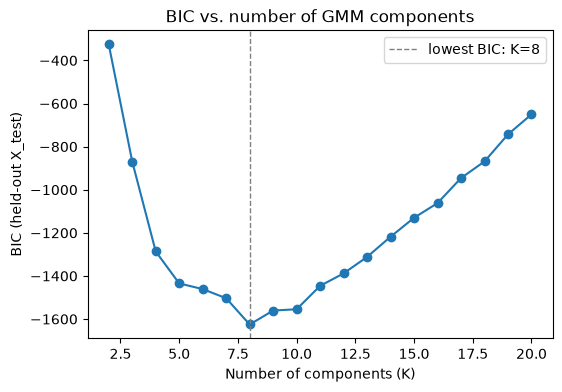

K= 2  BIC=-326.1022
K= 3  BIC=-869.1160
K= 4  BIC=-1286.2986
K= 5  BIC=-1434.6861
K= 6  BIC=-1460.9095
K= 7  BIC=-1503.4640
K= 8  BIC=-1625.2666  <-- lowest BIC
K= 9  BIC=-1560.6034
K=10  BIC=-1554.5365
K=11  BIC=-1445.9656
K=12  BIC=-1388.1880
K=13  BIC=-1311.7509
K=14  BIC=-1218.1675
K=15  BIC=-1130.1375
K=16  BIC=-1061.9607
K=17  BIC=-945.8297
K=18  BIC=-868.7085
K=19  BIC=-743.0587
K=20  BIC=-650.3962


In [5]:
K_candidates = K_CANDIDATES
bic_scores = []
for k in K_candidates:
    candidate = GMMClassifier(n_components=k, random_state=0,
                              reg_covar=REG_COVAR).fit(X_train, Y_train)
    bic_scores.append(candidate.bic(X_test))

best_k = K_candidates[int(np.argmin(bic_scores))]
warn_if_k_at_edge(best_k, K_candidates, " in the BIC sweep")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(K_candidates), bic_scores, marker="o")
ax.axvline(best_k, color="0.5", linestyle="--", linewidth=1,
           label=f"lowest BIC: K={best_k}")
ax.set_xlabel("Number of components (K)")
ax.set_ylabel("BIC (held-out X_test)")
ax.set_title("BIC vs. number of GMM components")
ax.legend()
plt.show()

for k, bic_val in zip(K_candidates, bic_scores):
    flag = "  <-- lowest BIC" if k == best_k else ""
    print(f"K={k:2d}  BIC={bic_val:9.4f}{flag}")

## Moving forward

Pick the K, and let's make a matrix. 

BIC: -1625.2666
Balanced accuracy score: 0.9972


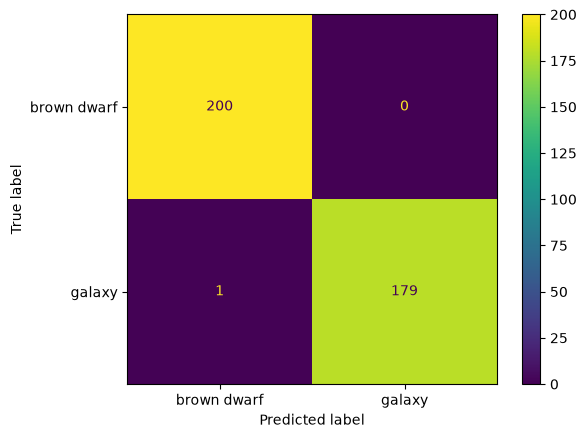

In [6]:
K = best_k

clf = GMMClassifier(n_components=K, random_state=0,
                    reg_covar=REG_COVAR).fit(X_train, Y_train)
pred_best = clf.predict(X_test)
score = clf.score(X_test, Y_test)

matrix = ConfusionMatrixDisplay.from_predictions(
    Y_test, pred_best, display_labels=["brown dwarf", "galaxy"]
)

bic = clf.bic(X_test)
print(f"BIC: {bic:.4f}")
print(f"Balanced accuracy score: {score:.4f}")

### Component Comp
We want to double check the components we have to flag any irrigularities

In [7]:
import pandas as pd

table = pd.DataFrame(clf.component_table(X_train, Y_train)).sort_values("margin")
table

,component,assigned_class,weight,margin,degenerate,mass_class_0.0,n_class_0.0,mass_class_1.0,n_class_1.0
0,0,0.0,0.062644,0.086777,False,1.036928e-01,63,1.691552e-02,9
5,5,1.0,0.059471,0.125306,False,8.819781e-08,0,1.253056e-01,69
2,2,1.0,0.064252,0.135625,False,8.829786e-08,0,1.356247e-01,75
7,7,0.0,0.101897,0.194103,False,1.941026e-01,119,3.581284e-29,0
6,6,1.0,0.119489,0.253317,False,2.610927e-08,0,2.533173e-01,129
1,1,0.0,0.176953,0.336377,False,3.363771e-01,203,7.480631e-43,0
3,3,0.0,0.192847,0.365827,False,3.658273e-01,215,3.918872e-20,0
4,4,1.0,0.222447,0.468837,False,1.283476e-21,0,4.688368e-01,258


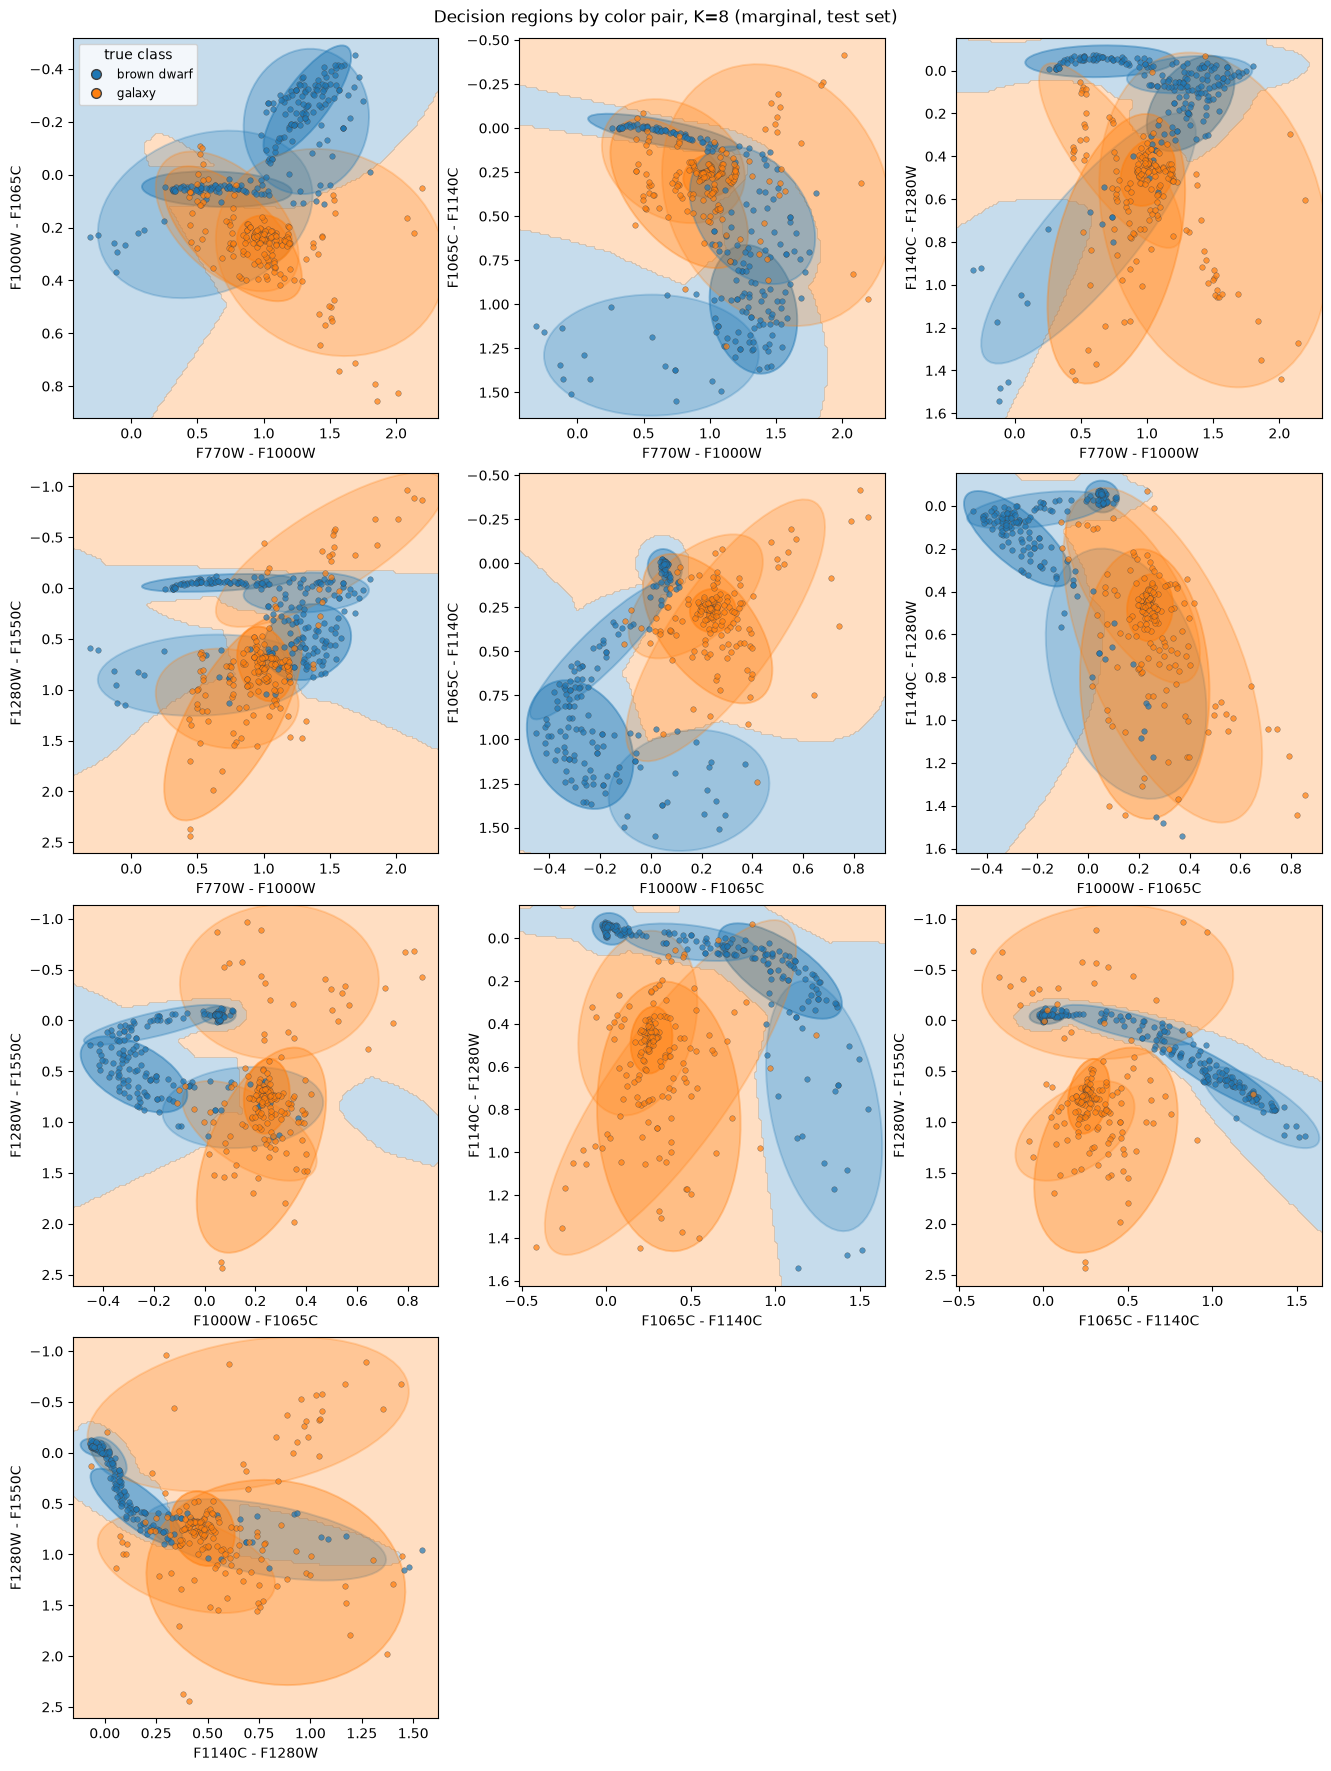

In [8]:
# One panel per pair of color axes. With d colors there are C(d, 2) planes and no
# reason to privilege one, so draw them all -- 3 colors gives 3 panels.
#
# mode="marginal" integrates the off-panel colors out under the fitted mixture:
# each panel answers "what would this classifier decide knowing only these two
# colors?". That is a projection, not a cross-section, so two classes that look
# tangled in one panel may be cleanly split by the color that panel isn't
# showing. Compare against mode="slice" (next cell) before reading too much into
# any single panel.
class_colors = ccp.class_color_map(clf.classes_)

fig, axes, pairs = ccp.plot_decision_grid(
    clf, X_test, Y_test, names,
    mode="marginal",
    class_colors=class_colors,
    class_labels=CLASS_LABELS,
    suptitle=f"Decision regions by color pair, K={K} (marginal, test set)")
plt.show()


### The same planes, as a slice instead of a projection

A 2-D panel cannot show a 3-D decision boundary, so there are two different
honest pictures and they answer different questions. Drawing both is the check
that neither is misleading you.

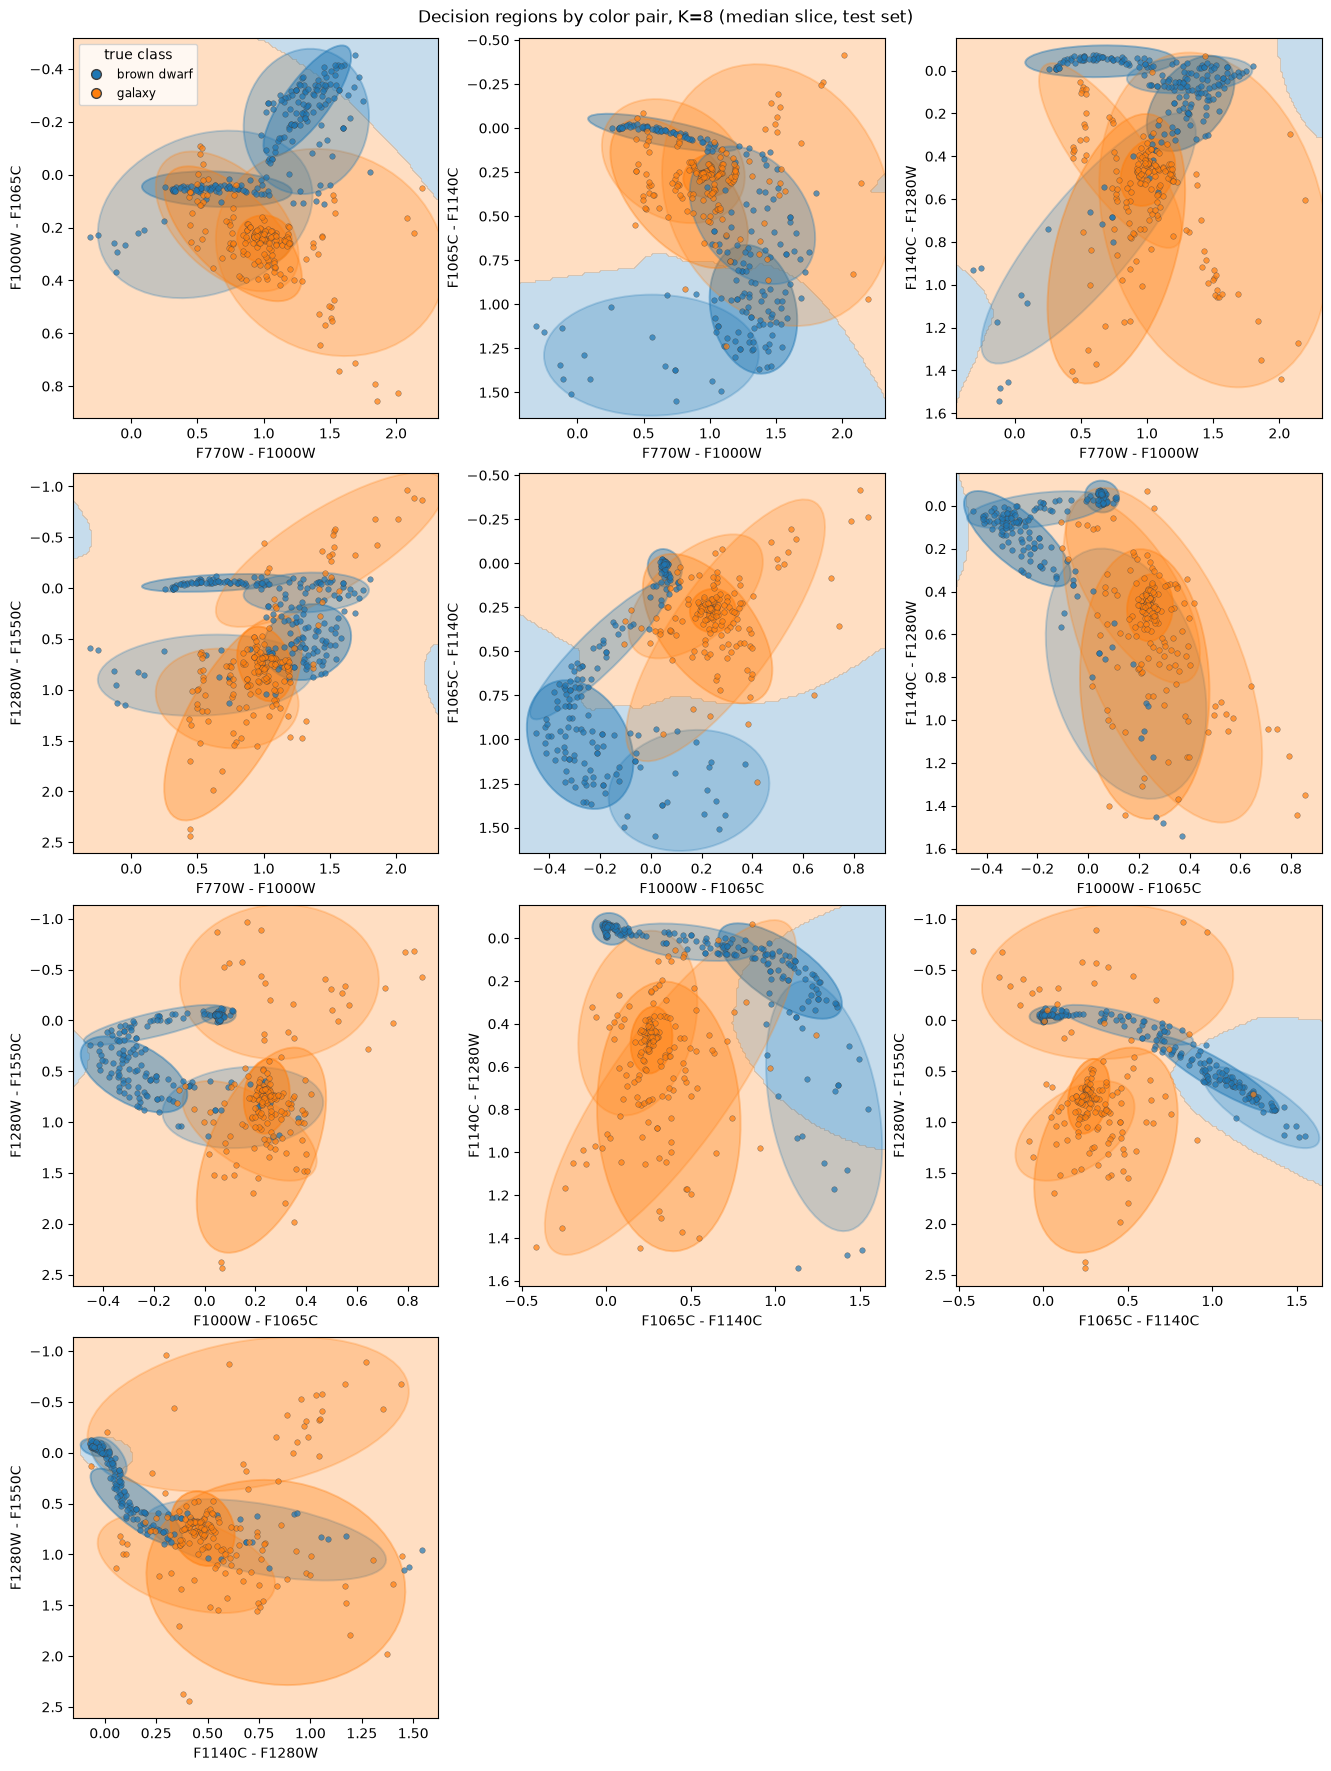

In [9]:
# The same planes as a genuine cross-section: hold the off-panel colors fixed at
# their median and evaluate the real d-dimensional classifier there. Unlike the
# marginal figure this IS a slice of the true boundary -- but only of that one
# cut, and most of the plotted points do not lie on it.
#
# Panels that disagree between the two figures are the interesting ones: there,
# the off-panel color is doing real classification work.
fig, axes, pairs = ccp.plot_decision_grid(
    clf, X_test, Y_test, names,
    mode="slice",
    class_colors=class_colors,
    class_labels=CLASS_LABELS,
    suptitle=f"Decision regions by color pair, K={K} (median slice, test set)")
plt.show()


## Which dwarfs fail

Trace the misclassified test-set dwarfs back to `bobcat_planets` via `idx_test`
and look at where they sit in T_eff -- do failures cluster at one end of the
sequence, or spread evenly? One projection panel per color pair, since a dwarf
that looks lost in one plane may be well separated in another.

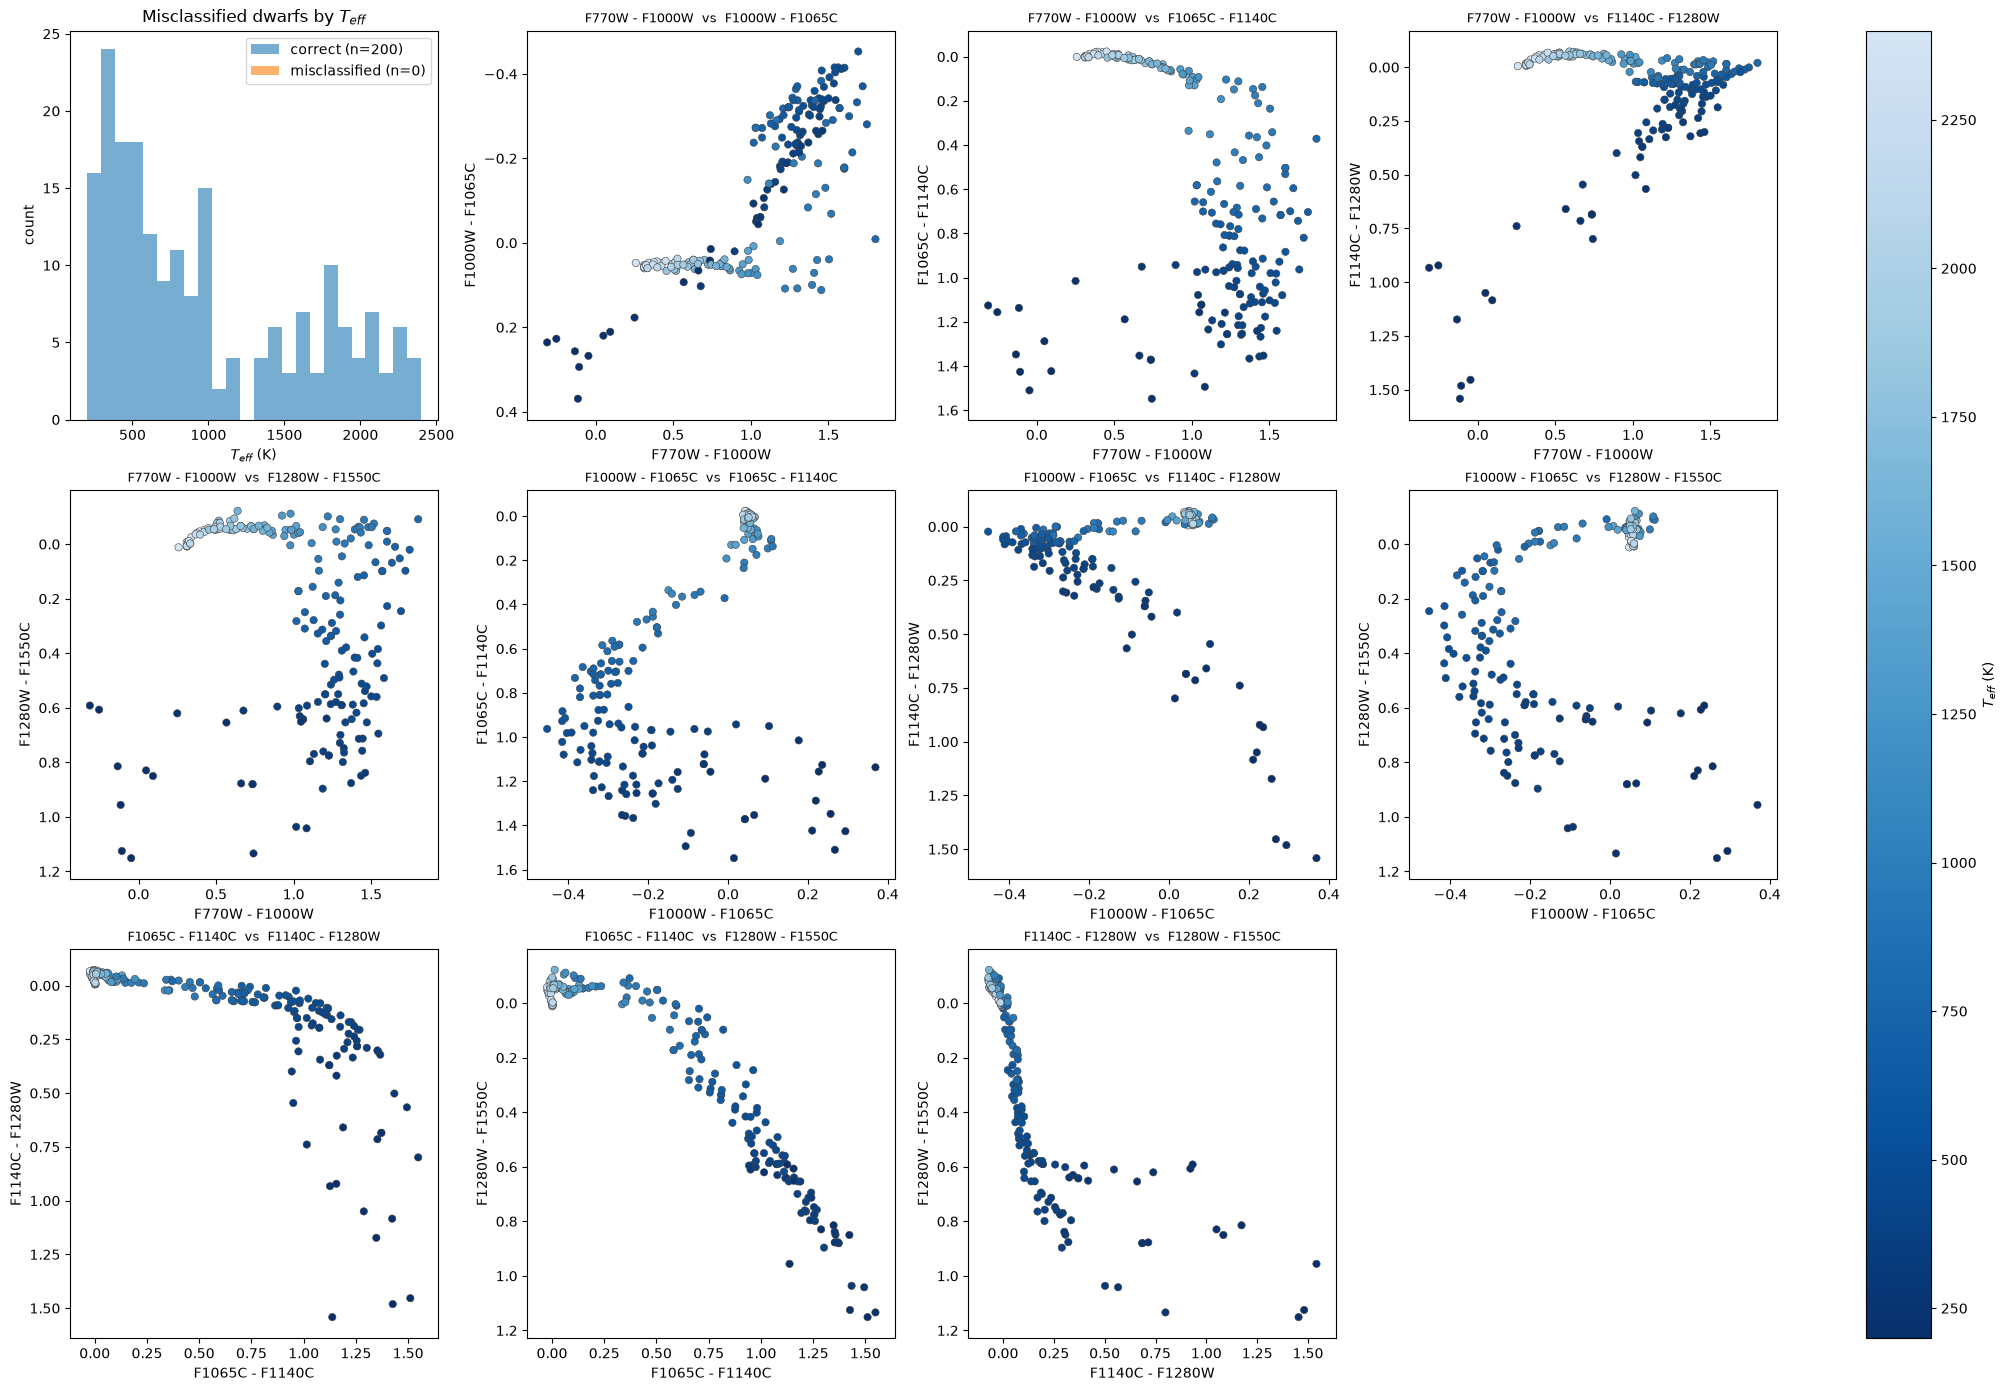

0 / 200 test-set dwarfs misclassified as galaxy


In [10]:
from matplotlib.colors import Normalize

# Metadata aligned to X_test's rows. A test row is a dwarf exactly when its
# original index lands below n_planets; galaxy rows keep nan and are dropped by
# the cls= mask inside plot_failures, never reaching a scatter call.
dwarf_rows = idx_test < n_planets
teff_test = np.full(len(idx_test), np.nan)
teff_test[dwarf_rows] = bobcat_planets["teff"][idx_test[dwarf_rows]]
assert np.array_equal(dwarf_rows, Y_test == DWARF_CLASS)

is_dwarf = Y_test == DWARF_CLASS
wrong = is_dwarf & (pred_best != DWARF_CLASS)

pairs = ccp.feature_pairs(X.shape[1])
n_panels = 1 + len(pairs)
ncols = min(4, n_panels)
nrows = int(np.ceil(n_panels / ncols))
# layout="constrained" measures the long y labels ("F1140C - F1550C") and the
# spanning colorbar before placing the axes, so labels stop bleeding into the
# panel to their left. Set at creation -- a later tight_layout() cannot handle a
# colorbar attached to several axes at once.
fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 4.6 * nrows),
                         squeeze=False, layout="constrained")
axes = axes.ravel()

bins = np.linspace(np.nanmin(teff_test), np.nanmax(teff_test), 25)
axes[0].hist(teff_test[is_dwarf & (pred_best == DWARF_CLASS)], bins=bins,
             alpha=0.6, label=f"correct (n={int((is_dwarf & (pred_best == DWARF_CLASS)).sum())})")
axes[0].hist(teff_test[wrong], bins=bins, alpha=0.6,
             label=f"misclassified (n={int(wrong.sum())})")
axes[0].set_xlabel("$T_{eff}$ (K)")
axes[0].set_ylabel("count")
axes[0].legend()
axes[0].set_title("Misclassified dwarfs by $T_{eff}$")

# One shared Normalize across every panel, so a given blue means the same
# temperature no matter which color pair you are looking at.
norm = Normalize(vmin=np.nanmin(teff_test), vmax=np.nanmax(teff_test))

for ax, pair in zip(axes[1:], pairs):
    handle, n_wrong, n_total = ccp.plot_failures(
        ax, X_test, Y_test, pred_best, cls=DWARF_CLASS, dims=pair,
        c=teff_test, cmap=ccp.DWARF_CMAP, norm=norm)
    ccp.style_panel(ax, names[pair[0]], names[pair[1]])
    ax.set_title(f"{names[pair[0]]}  vs  {names[pair[1]]}", fontsize=9)

for ax in axes[n_panels:]:
    ax.set_visible(False)

fig.colorbar(handle, ax=axes[1:n_panels].tolist(), label="$T_{eff}$ (K)")
plt.show()

print(f"{int(wrong.sum())} / {int(is_dwarf.sum())} test-set dwarfs misclassified as galaxy")


## Which galaxies fail

The galaxy-side counterpart. Galaxies have no T_eff, but they do have the axes
their tracks are built along: redshift, plus which K15 AGN-fraction template they
came from. Both are recovered from `idx_test` through the same `n_planets` offset
the setup cell defined, so this no longer depends on the old `all_g_color_1`
variables.

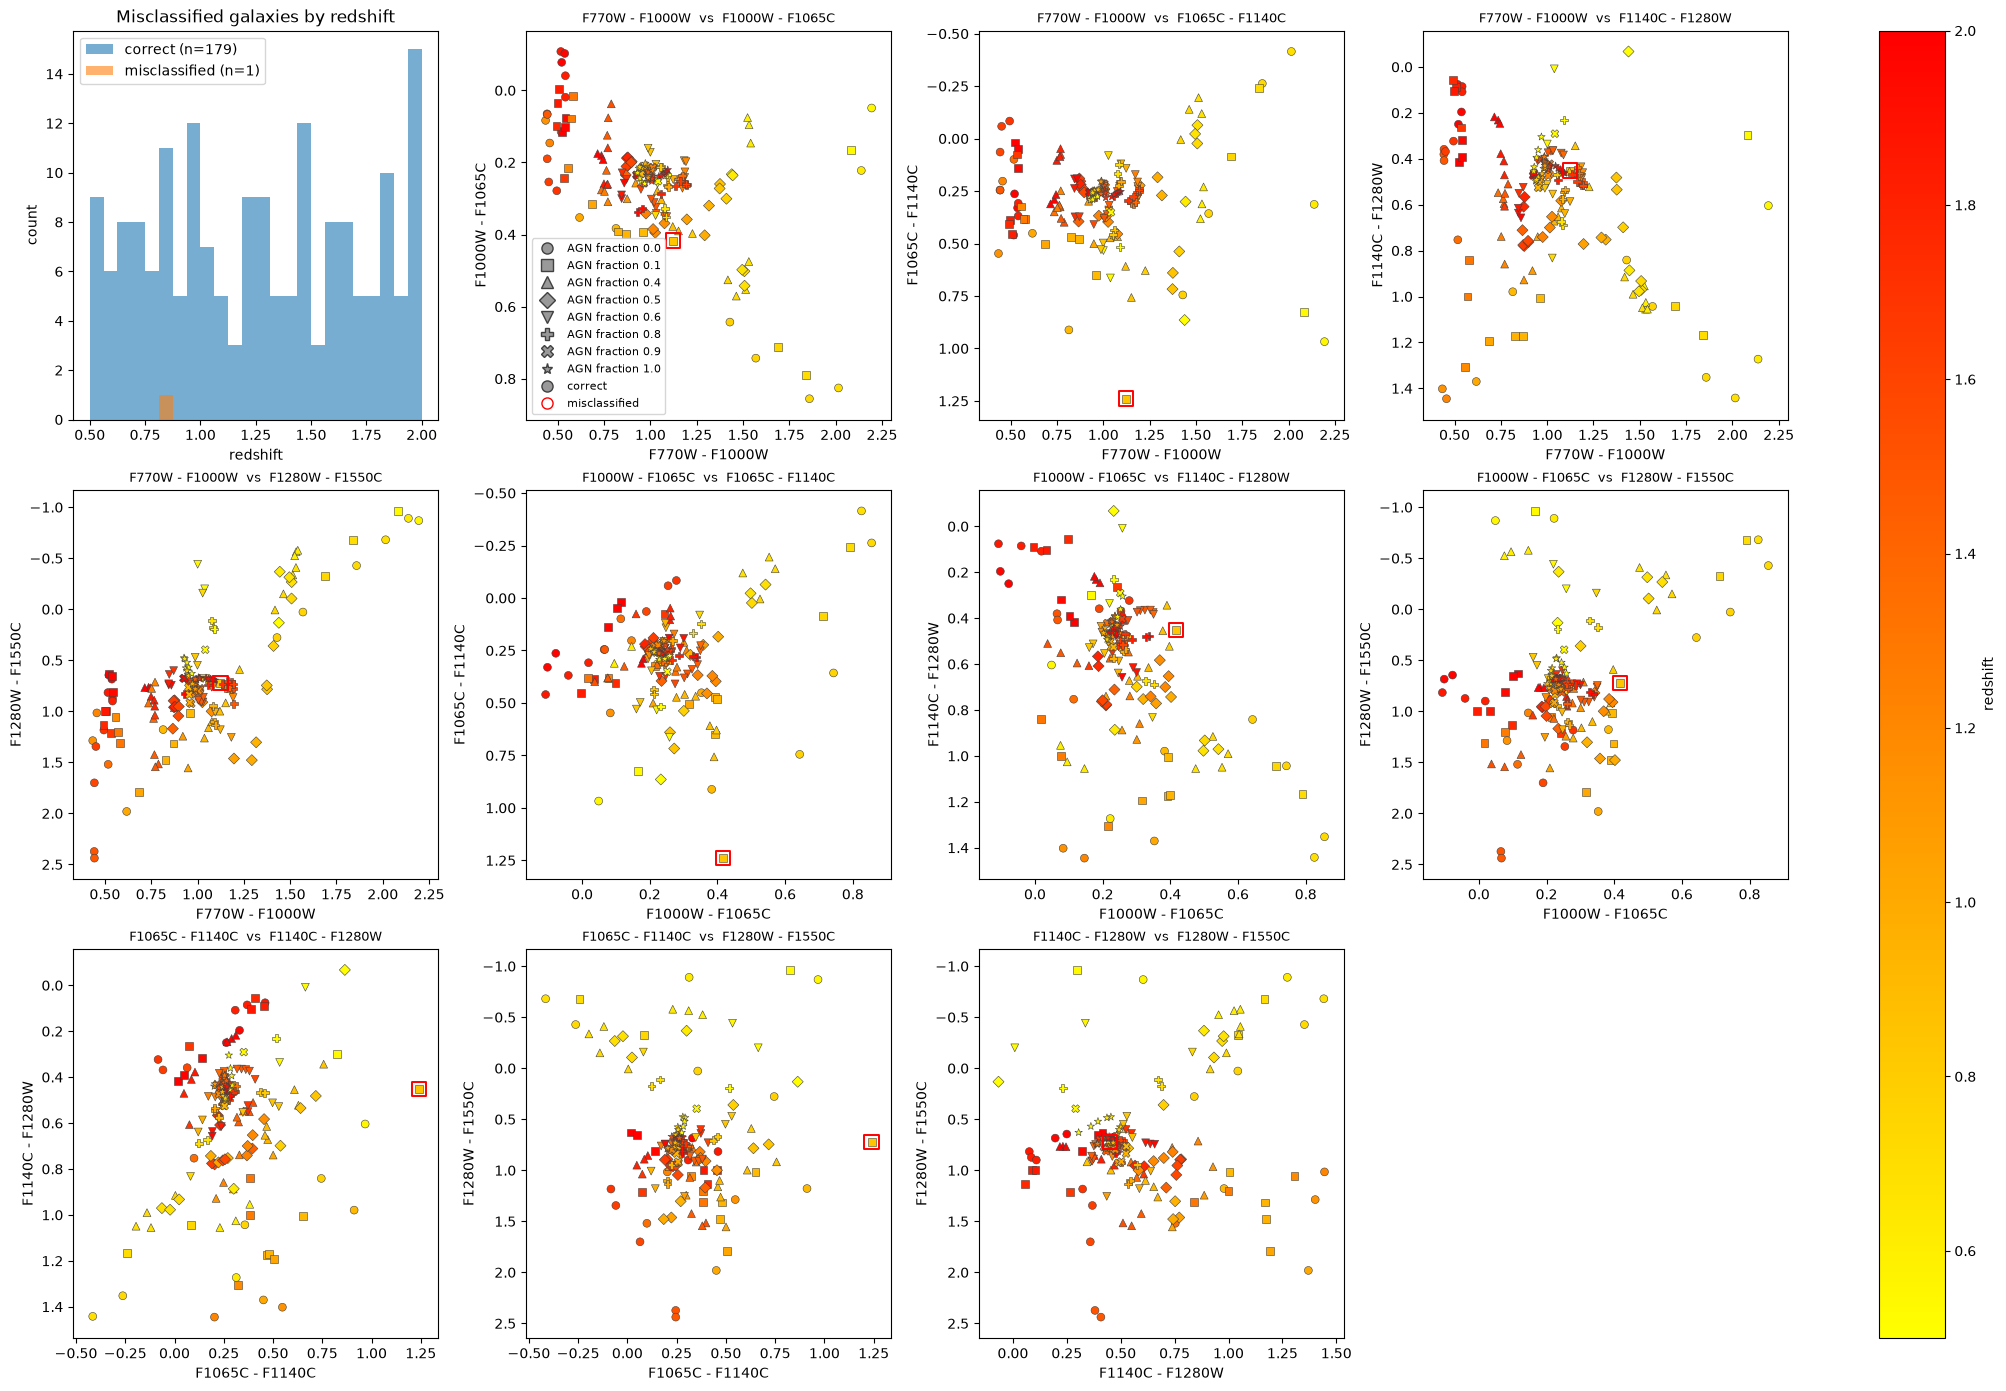

1 / 180 test-set galaxies misclassified as brown dwarf
AGN fraction 0.0: 0 / 21 misclassified
AGN fraction 0.1: 1 / 18 misclassified
AGN fraction 0.4: 0 / 30 misclassified
AGN fraction 0.5: 0 / 22 misclassified
AGN fraction 0.6: 0 / 25 misclassified
AGN fraction 0.8: 0 / 20 misclassified
AGN fraction 0.9: 0 / 14 misclassified
AGN fraction 1.0: 0 / 30 misclassified


In [11]:
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

# Galaxy-side metadata aligned to X_test's rows, via the same offset rule.
galaxy_rows = idx_test >= n_planets
z_test = np.full(len(idx_test), np.nan)
agn_test = np.full(len(idx_test), np.nan)
z_test[galaxy_rows] = all_g_redshift[idx_test[galaxy_rows] - n_planets]
agn_test[galaxy_rows] = all_g_agn_frac[idx_test[galaxy_rows] - n_planets]
assert np.array_equal(galaxy_rows, Y_test == GALAXY_CLASS)

is_galaxy = Y_test == GALAXY_CLASS
wrong = is_galaxy & (pred_best != GALAXY_CLASS)

pairs = ccp.feature_pairs(X.shape[1])
n_panels = 1 + len(pairs)
ncols = min(4, n_panels)
nrows = int(np.ceil(n_panels / ncols))
# layout="constrained" measures the long y labels ("F1140C - F1550C") and the
# spanning colorbar before placing the axes, so labels stop bleeding into the
# panel to their left. Set at creation -- a later tight_layout() cannot handle a
# colorbar attached to several axes at once.
fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 4.6 * nrows),
                         squeeze=False, layout="constrained")
axes = axes.ravel()

bins = np.linspace(np.nanmin(z_test), np.nanmax(z_test), 25)
axes[0].hist(z_test[is_galaxy & (pred_best == GALAXY_CLASS)], bins=bins,
             alpha=0.6, label=f"correct (n={int((is_galaxy & (pred_best == GALAXY_CLASS)).sum())})")
axes[0].hist(z_test[wrong], bins=bins, alpha=0.6,
             label=f"misclassified (n={int(wrong.sum())})")
axes[0].set_xlabel("redshift")
axes[0].set_ylabel("count")
axes[0].legend()
axes[0].set_title("Misclassified galaxies by redshift")

# AGN fraction is categorical, so it gets marker shape rather than fighting
# redshift for the color scale. All markers share one Normalize so the colorbar
# means the same thing for every shape -- and one marker per template means this
# adapts if GALAXY_AGN_FRACTIONS grows. Eleven shapes covers the full K15 MIR
# library (MIR0.0 - MIR1.0); past that the cycle repeats and two templates
# become indistinguishable in the panels, so say so rather than mislead.
markers = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h"]
if len(GALAXY_AGN_FRACTIONS) > len(markers):
    print(f"  WARNING: {len(GALAXY_AGN_FRACTIONS)} templates but only "
          f"{len(markers)} marker shapes -- shapes repeat and the legend is "
          "ambiguous. Add markers or split the figure.")

# Sorted by AGN fraction, NOT by GALAXY_TEMPLATE_FILES order. That tuple is
# ordered by when each template was added, which is meaningless to a reader, so
# the legend read 0.0, 0.5, 1.0, 0.1, ... Sorting here is presentation only: it
# fixes the legend order and the shape-to-fraction assignment, and touches
# nothing that feeds the fit. The row order in X stays as it was, so no numbers
# move.
AGN_FRACTIONS_SORTED = tuple(sorted(GALAXY_AGN_FRACTIONS))
agn_markers = {frac: markers[i % len(markers)]
               for i, frac in enumerate(AGN_FRACTIONS_SORTED)}

# ccp.GALAXY_CMAP is matplotlib's "autumn", which runs red -> yellow, putting
# red at the LOW-redshift end. Reversed, the most redshifted objects are the
# reddest -- the direction the eye already expects from the word "redshift".
# Reversed at the call site rather than in dwarfhunt.plots on purpose:
# GALAXY_CMAP also colours the galaxy tracks in michelson-gmm-exploration,
# whose figures Log.md refers to.
GALAXY_Z_CMAP = ccp.GALAXY_CMAP.reversed()

norm = Normalize(vmin=np.nanmin(z_test), vmax=np.nanmax(z_test))

for ax, pair in zip(axes[1:], pairs):
    for frac, marker in agn_markers.items():
        handle, _, _ = ccp.plot_failures(
            ax, X_test, Y_test, pred_best, cls=GALAXY_CLASS, dims=pair,
            c=z_test, cmap=GALAXY_Z_CMAP, norm=norm, marker=marker, size=32,
            subset=agn_test == frac)
    ccp.style_panel(ax, names[pair[0]], names[pair[1]])
    ax.set_title(f"{names[pair[0]]}  vs  {names[pair[1]]}", fontsize=9)

shape_handles = [Line2D([], [], marker=marker, linestyle="none", markerfacecolor="0.6",
                        markeredgecolor="0.25", markersize=8, label=f"AGN fraction {frac}")
                 for frac, marker in agn_markers.items()]
status_handles = [
    Line2D([], [], marker="o", linestyle="none", markerfacecolor="0.6",
           markeredgecolor="0.25", markersize=8, label="correct"),
    Line2D([], [], marker="o", linestyle="none", markerfacecolor="none",
           markeredgecolor="red", markersize=8, label="misclassified"),
]
axes[1].legend(handles=shape_handles + status_handles, fontsize=8, loc="best")

for ax in axes[n_panels:]:
    ax.set_visible(False)

fig.colorbar(handle, ax=axes[1:n_panels].tolist(), label="redshift")
plt.show()

print(f"{int(wrong.sum())} / {int(is_galaxy.sum())} test-set galaxies misclassified as brown dwarf")
for frac in AGN_FRACTIONS_SORTED:
    n_total = int(np.sum(agn_test == frac))
    n_wrong = int(np.sum((agn_test == frac) & wrong))
    print(f"AGN fraction {frac}: {n_wrong} / {n_total} misclassified")


## Does the extra color actually help?

This cell is meant to determine if adding additional color values actuall improve the balanced accuracy, and how much headroom we gain for each additional color value. We're going to do a refit across the same 20 train/test splits. During this sequence, we're going to recalcuate K, so that it doesn't confound the model, and we get the best value coming out of as we can.

This will output multiple values to view:

**The balanced accuracy +- standard deviation.** This is the basic balanced accuracy vs std that we've been using in other places in the project. 

**The paired difference.** We want to be able to determine that the extra color helped overall, not just particular sets that were nicer to the model. So we compare them based on the same split, which makes it a better comparison. Splits vary in difficulty, and that variation is shared by every color set tested on them. Subtracting within a split removes that difficulty, so what's left is the effect of the color itself. The variance reported is sem not std, as we want to answer "is the improvement real", and not "how much does a split wobble."

**The win count.** We want an actual improvment count, which is more convincing than a mean, and it doesn't assume the differences are normal.

**The K distribution.** If we land on the same K often, then we're finding actual structure. If we get a wide range, then we're hitting a lot of noise and not adding a ton of value. 

In [12]:
N_SEEDS = 20
TEST_SIZE = 0.4

# Nested prefixes of the color list. Color i is FILTER_LABELS[i] -
# FILTER_LABELS[i+1], so a prefix of length m spans FILTER_LABELS[:m+1] and each
# step adds exactly one filter and one independent color.
COLOR_SET_SIZES = list(range(2, X.shape[1] + 1))

results = {}
for m in COLOR_SET_SIZES:
    cols = list(range(m))
    scores = np.empty(N_SEEDS)
    chosen_k = np.empty(N_SEEDS, dtype=int)

    for seed in range(N_SEEDS):
        Xtr, Xte, ytr, yte = train_test_split(
            X[:, cols], Y, test_size=TEST_SIZE, stratify=Y, random_state=seed)

        # GMM random_state pinned so only the split varies from seed to seed.
        fits = [GMMClassifier(n_components=k, random_state=0,
                              reg_covar=REG_COVAR).fit(Xtr, ytr)
                for k in K_CANDIDATES]
        best = int(np.argmin([f.bic(Xtr) for f in fits]))

        chosen_k[seed] = K_CANDIDATES[best]
        scores[seed] = fits[best].score(Xte, yte)

    results[m] = {"scores": scores, "k": chosen_k}
    n_edge = int(np.sum((chosen_k == K_CANDIDATES[0]) | (chosen_k == K_CANDIDATES[-1])))
    if n_edge:
        warn_if_k_at_edge(int(chosen_k[np.argmax(
            (chosen_k == K_CANDIDATES[0]) | (chosen_k == K_CANDIDATES[-1]))]),
            K_CANDIDATES, f" on {n_edge}/{N_SEEDS} splits at {m} colours")
    print(f"{m} colors ({', '.join(FILTER_LABELS[:m + 1])}) done")

print(f"\n{'colors':<8}{'filters':<36}{'bal. acc (mean +- std)':<28}{'K median [min-max]'}")
for m in COLOR_SET_SIZES:
    s, k = results[m]["scores"], results[m]["k"]
    acc = f"{s.mean():.4f} +- {s.std(ddof=1):.4f}"
    print(f"{m:<8}{' '.join(FILTER_LABELS[:m + 1]):<36}{acc:<28}"
          f"{int(np.median(k))} [{k.min()}-{k.max()}]")

# Paired against the smallest color set, on the same splits.
base_m = COLOR_SET_SIZES[0]
print(f"\nPaired against {base_m} colors, same {N_SEEDS} splits:")
for m in COLOR_SET_SIZES[1:]:
    d = results[m]["scores"] - results[base_m]["scores"]
    wins = int((d > 0).sum())
    ties = int((d == 0).sum())
    print(f"  +{m - base_m} color: mean diff {d.mean():+.4f} "
          f"+- {d.std(ddof=1) / np.sqrt(N_SEEDS):.4f} (sem of the difference), "
          f"better on {wins}/{N_SEEDS} splits, tied on {ties}")

# Headroom fraction: we want to see how much of the remaining error is removed by adding a color, not just the absolute gain. 
# 1 - err_new / err_base, with err = 1 - balanced accuracy.
#
# As a note, we're excluding splits where the baseline is already perfect, because those won't have headroom, which will make the ratio undefined. 
# Those splits are counted and reported, but not included in the mean.

print(f"\nHeadroom closed vs {base_m} colors (share of remaining balanced error removed):")
base_scores = results[base_m]["scores"]
for m in COLOR_SET_SIZES[1:]:
    new_scores = results[m]["scores"]
    headroom = 1.0 - base_scores
    usable = headroom > 0

    err_base = 1.0 - base_scores.mean()
    err_new = 1.0 - new_scores.mean()
    pooled = 1.0 - err_new / err_base if err_base > 0 else float("nan")

    if usable.sum() > 1:
        frac = (new_scores[usable] - base_scores[usable]) / headroom[usable]
        sem = frac.std(ddof=1) / np.sqrt(len(frac))
        per_split = (f"{100 * frac.mean():+.1f}% +- {100 * sem:.1f}% "
                     f"(per split, n={int(usable.sum())})")
    elif usable.sum() == 1:
        frac = (new_scores[usable] - base_scores[usable]) / headroom[usable]
        per_split = f"{100 * frac.mean():+.1f}% (only 1 usable split, no spread)"
    else:
        per_split = "undefined -- baseline is perfect on every split"

    print(f"  +{m - base_m} color: {per_split}")
    print(f"{'':>13}pooled from means {100 * pooled:+.1f}%   "
          f"balanced error {err_base:.4f} -> {err_new:.4f}")
    if not usable.all():
        print(f"{'':>13}{int((~usable).sum())} split(s) excluded: baseline already perfect")


print("\nSelected K per color set:")
for m in COLOR_SET_SIZES:
    vals, counts = np.unique(results[m]["k"], return_counts=True)
    spread = ", ".join(f"K={v}: {c}" for v, c in zip(vals, counts))
    print(f"  {m} colors -> {spread}")


2 colors (F770W, F1000W, F1065C) done
3 colors (F770W, F1000W, F1065C, F1140C) done
4 colors (F770W, F1000W, F1065C, F1140C, F1280W) done
5 colors (F770W, F1000W, F1065C, F1140C, F1280W, F1550C) done

colors  filters                             bal. acc (mean +- std)      K median [min-max]
2       F770W F1000W F1065C                 0.9092 +- 0.0148            8 [4-11]
3       F770W F1000W F1065C F1140C          0.9959 +- 0.0019            10 [8-14]
4       F770W F1000W F1065C F1140C F1280W   0.9995 +- 0.0017            12 [11-13]
5       F770W F1000W F1065C F1140C F1280W F1550C0.9991 +- 0.0024            13 [10-15]

Paired against 2 colors, same 20 splits:
  +1 color: mean diff +0.0867 +- 0.0032 (sem of the difference), better on 20/20 splits, tied on 0
  +2 color: mean diff +0.0903 +- 0.0032 (sem of the difference), better on 20/20 splits, tied on 0
  +3 color: mean diff +0.0899 +- 0.0032 (sem of the difference), better on 20/20 splits, tied on 0

Headroom closed vs 2 colors (share 

## Which filter combination separates best?

This is where we go through and sweep through the available filter subset using our cached magnitudes. 

**The statistics are the hard part, not the compute.** Score N candidates, take
the best, and that winner is inflated even if every candidate is equally good:
you are reporting the maximum of N noisy draws. The cell prints the size of that
effect for this many candidates, and it is usually comparable to the gaps near
the top of the table.

So the protocol is:

1. We're going to take 30% of the data, and seal it away as a final scoring for our top chosen models. This allows us to make sure that we don't get bias from runs that are particularly favorable to a certain filter breakdown.
2. We then run multiple subset, seed, and K selection inside the filter pool with the remaining data, calculating results, giving us a list of 5 finalists.
3. We then refit on the whole pool, and scored on the holdout data once. 
4. We then report that scored number.

The holdout is spent the moment you look at it and then go back and search
again. If you change the sweep after seeing holdout numbers, re-split first.

In [13]:
from dwarfhunt import search as fsearch

SUBSET_SIZES = range(3, len(FILTER_LABELS) + 1)   # 3+ filters => 2+ colours
HOLDOUT_FRAC = 0.30
SEARCH_SEEDS = 8      # internal splits per subset, inside the pool
SEARCH_N_INIT = 3     # cheaper than the headline fit; finalists get the full n_init
N_FINALISTS = 5

# Split once, before any subset is looked at.
pool_rows, holdout_rows = fsearch.holdout_split(
    Y, holdout_frac=HOLDOUT_FRAC, random_state=0)
print(f"search pool {len(pool_rows)} objects | holdout {len(holdout_rows)} "
      f"({int((Y[holdout_rows] == DWARF_CLASS).sum())} dwarfs, "
      f"{int((Y[holdout_rows] == GALAXY_CLASS).sum())} galaxies)")

planet_mags = {lab: bobcat_planets[f"abs_mag_{lab}"] for lab in FILTER_LABELS}
galaxy_mags = [{lab: g[f"mag_{lab}"] for lab in FILTER_LABELS} for g in all_galaxy_data]

results = fsearch.search_subsets(
    FILTER_LABELS, planet_mags, galaxy_mags, Y,
    sizes=SUBSET_SIZES, k_candidates=K_CANDIDATES, reg_covar=REG_COVAR,
    search_rows=pool_rows, n_seeds=SEARCH_SEEDS, n_init=SEARCH_N_INIT,
    progress=25)

print(f"\n{'rank':>4} {'search':>8} {'std':>7} {'K':>4} {'edge':>5}  filters")
for i, r in enumerate(results[:12], 1):
    print(f"{i:4d} {r['mean']:8.4f} {r['std']:7.4f} {int(np.median(r['k'])):4d} "
          f"{r['n_at_edge']:5d}  {'+'.join(r['subset'])}")
print(f"{'':4} {'...':>8}")
for r in results[-3:]:
    print(f"{'':4} {r['mean']:8.4f} {r['std']:7.4f} {int(np.median(r['k'])):4d} "
          f"{r['n_at_edge']:5d}  {'+'.join(r['subset'])}")

# "edge" counts splits where BIC's chosen K sat on a boundary of K_CANDIDATES.
# Non-zero means that subset was capped while others may not have been, so the
# ranking is not comparing them on equal terms -- widen K_CANDIDATES or raise
# REG_COVAR and rerun before trusting the order.
total_edge = sum(r["n_at_edge"] for r in results)
if total_edge:
    print(f"\n{total_edge} K-selections hit a range boundary across the sweep.")

# How big a gap has to be before it means anything.
sigma = float(np.median([r["std"] for r in results]))
inflation = fsearch.winners_curse(len(results), sigma, SEARCH_SEEDS)
gap = results[0]["mean"] - results[1]["mean"]
print(f"\nwinner's curse: {len(results)} candidates, per-split sigma {sigma:.4f}")
print(f"  best-of-N is inflated by roughly {inflation:+.4f} even with no real differences")
print(f"  rank1 - rank2 = {gap:+.4f} -> "
      f"{'WITHIN the noise floor; treat the top group as tied' if gap < inflation else 'larger than the noise floor'}")
tied = [r for r in results if results[0]["mean"] - r["mean"] < inflation]
print(f"  {len(tied)} subset(s) sit within one noise floor of the top")

search pool 1064 objects | holdout 456 (240 dwarfs, 216 galaxies)
  25/42 subsets
  42/42 subsets

rank   search     std    K  edge  filters
   1   1.0000  0.0000    9     0  F1000W+F1065C+F1280W+F1550C
   2   1.0000  0.0000   12     0  F770W+F1000W+F1065C+F1140C+F1550C
   3   1.0000  0.0000   13     0  F770W+F1000W+F1065C+F1280W+F1550C
   4   1.0000  0.0000   14     0  F770W+F1000W+F1065C+F1140C+F1280W+F1550C
   5   0.9996  0.0012   11     0  F770W+F1000W+F1065C+F1140C+F1280W
   6   0.9992  0.0015   13     0  F770W+F1065C+F1140C+F1280W+F1550C
   7   0.9979  0.0024    8     0  F770W+F1000W+F1065C+F1140C
   8   0.9963  0.0057   11     0  F1000W+F1065C+F1140C+F1280W+F1550C
   9   0.9959  0.0042    9     0  F1000W+F1065C+F1140C+F1550C
  10   0.9936  0.0055   10     0  F770W+F1065C+F1140C+F1550C
  11   0.9923  0.0057   13     0  F770W+F1000W+F1140C+F1280W+F1550C
  12   0.9918  0.0053    7     0  F1065C+F1140C+F1280W+F1550C
          ...
       0.8289  0.0388   10     0  F770W+F1000W+F1550C

### The only number worth quoting

Finalists refit on the entire search pool, then scored once on the holdout that we haven't unsealed. We're expecting the holdout score to be lower, as the winner's curse will come back into effect. 

In [14]:
holdout_rank = []
for r in results[:N_FINALISTS]:
    h = fsearch.evaluate_on_holdout(
        r["subset"], planet_mags, galaxy_mags, Y, pool_rows, holdout_rows,
        k_candidates=K_CANDIDATES, reg_covar=REG_COVAR)
    h["search_mean"] = r["mean"]
    holdout_rank.append(h)

print(f"{'search':>8} {'holdout':>9} {'drop':>8} {'K':>4}  filters")
for h in holdout_rank:
    drop = h["search_mean"] - h["holdout_score"]
    print(f"{h['search_mean']:8.4f} {h['holdout_score']:9.4f} {drop:+8.4f} "
          f"{h['k']:4d}  {'+'.join(h['subset'])}")

best = max(holdout_rank, key=lambda h: h["holdout_score"])
print(f"\nbest on the holdout: {'+'.join(best['subset'])} "
      f"({len(best['subset'])} filters, {len(best['subset'])-1} colours) "
      f"-> {best['holdout_score']:.4f}")

# Prefer the smallest subset that ties the best, not the highest-scoring one:
# fewer filters is cheaper to observe and the difference is inside the noise.
ties = [h for h in holdout_rank
        if best["holdout_score"] - h["holdout_score"] < inflation]
cheapest = min(ties, key=lambda h: len(h["subset"]))
if cheapest["subset"] != best["subset"]:
    print(f"cheapest subset within one noise floor: {'+'.join(cheapest['subset'])} "
          f"({len(cheapest['subset'])} filters) -> {cheapest['holdout_score']:.4f}")

  search   holdout     drop    K  filters
  1.0000    1.0000  +0.0000   11  F1000W+F1065C+F1280W+F1550C
  1.0000    1.0000  +0.0000   13  F770W+F1000W+F1065C+F1140C+F1550C
  1.0000    1.0000  +0.0000   15  F770W+F1000W+F1065C+F1280W+F1550C
  1.0000    1.0000  +0.0000   12  F770W+F1000W+F1065C+F1140C+F1280W+F1550C
  0.9996    1.0000  -0.0004   13  F770W+F1000W+F1065C+F1140C+F1280W

best on the holdout: F1000W+F1065C+F1280W+F1550C (4 filters, 3 colours) -> 1.0000


## Where it falls apart once the data has error bars

Every number above this point was computed on noiseless photometry. Dwarf colours
are an exact function of `(teff, logg, feh)` and galaxy colours an exact function
of `z`, so both populations lie on manifolds with no scatter at all, and a
balanced accuracy of `1.0000` is partly a statement about that rather than about
the filters. This cell puts the error bars back and sweeps how big they have to
get before the separation stops working.

Noise is injected on the **magnitudes**, one independent draw per object per
filter, and the colours are then recomputed from the perturbed magnitudes. That
matters: a colour is a difference of two bands, so per-band scatter arrives in
the colours already correlated -- each colour picks up `sqrt(2) * sigma`, and two
adjacent colours share a filter, which gives them covariance `-sigma^2`.
Perturbing the columns of `X` directly would discard that structure and make the
noise look gentler than it is.

Two regimes get scored at every sigma, because "add error bars" has two meanings
and they break in different places:

**Noisy train, noisy test.** Fit on noisy colours, score on noisy colours. This
is the honest survey case -- you never had the noiseless data to begin with, and
the fit gets to learn how wide the populations actually are.

**Clean train, noisy test.** Fit on the noiseless model grid, score on noisy
colours. This is the transfer case, and it is what this notebook has implicitly
been claiming: the classifier is built from Sonora-Bobcat and K15 templates, and
would then be pointed at real photometry. Here the fitted covariances describe a
manifold that the test points no longer sit on.

`K` is re-selected by BIC at every sigma rather than pinned at the noiseless
optimum. Noise is exactly what erases the fine structure BIC was counting, so
holding `K` fixed would confound "the noise hurts" with "`K` is now wrong for
this data". The second panel tracks that selection, and it is its own result:
`K` falls monotonically as sigma rises, and once it lands on the bottom of
`K_CANDIDATES` the value is a cap rather than a choice.

One thing to read off the first panel: the curve is flat until roughly
`sqrt(REG_COVAR / 2)`. `REG_COVAR` is a variance floor on the colours and an
injected sigma contributes `2 * sigma^2` of colour variance, so below that point
the floor already assumes more scatter than we are adding and the fit genuinely
cannot see it. That is the quantitative version of the claim in the setup cell
that `REG_COVAR` stands in for the photometric uncertainty a model-only study has
no way to supply -- and it also means the breakdown sigma reported here is not
independent of that setting.

 sigma    SNR |        noisy-train |        clean-train |    K    range  edge
 0.000    inf | 1.0000 +- 0.0000 | 1.0000 +- 0.0000 |   14  13-16       0
 0.005  217.2 | 1.0000 +- 0.0000 | 1.0000 +- 0.0000 |   13  13-16       0
 0.010  108.6 | 1.0000 +- 0.0000 | 1.0000 +- 0.0000 |   12  12-14       0
 0.020   54.3 | 1.0000 +- 0.0000 | 1.0000 +- 0.0000 |   13  12-15       0
 0.050   21.7 | 0.9954 +- 0.0057 | 0.9951 +- 0.0055 |    9   8-11       0
 0.100   10.9 | 0.9850 +- 0.0067 | 0.9450 +- 0.0349 |    7   7-8        0
 0.150    7.2 | 0.9387 +- 0.0061 | 0.8470 +- 0.0375 |    5   5-5        0
 0.200    5.4 | 0.8883 +- 0.0371 | 0.7554 +- 0.0371 |    4   4-5        0
 0.300    3.6 | 0.7397 +- 0.0320 | 0.6552 +- 0.0180 |    3   2-3        2
 0.500    2.2 | 0.5546 +- 0.0386 | 0.5642 +- 0.0219 |    2   2-2        6

noiseless control: noisy-train 1.0000, clean-train 1.0000   (both should read 1.0000)
REG_COVAR=0.001 floors the colour scatter at sqrt(REG_COVAR/2) = 0.022 mag (SNR 49); below that

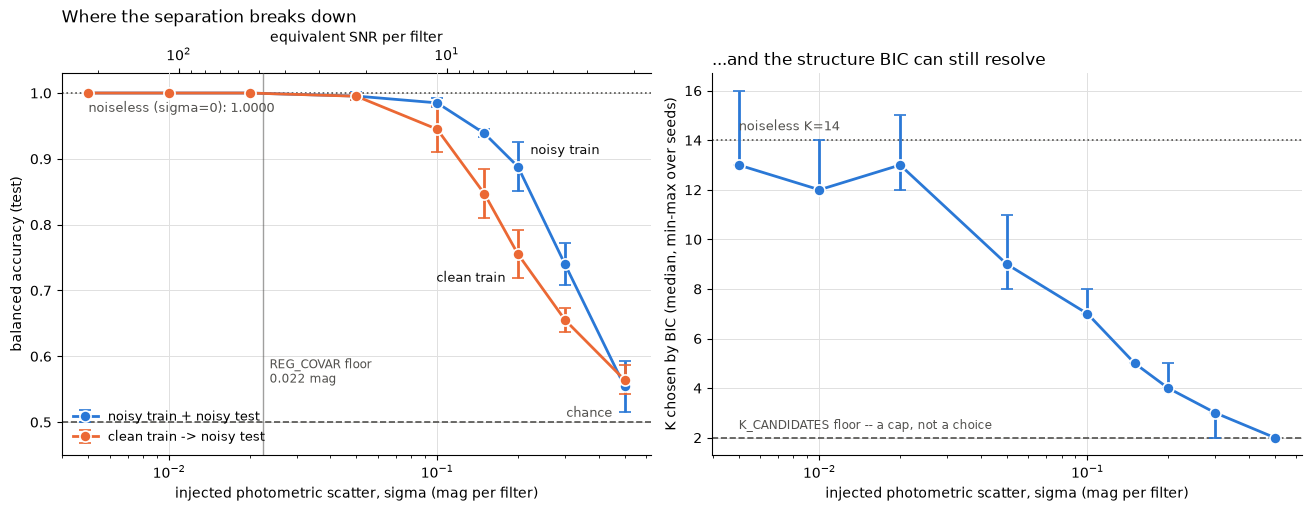

In [15]:
from dwarfhunt import search as fsearch

# Photometric scatter to inject, in magnitudes per filter. sigma=0 is the
# control: it must reproduce the noiseless headline score, and if it does not,
# something in this cell disagrees with the rest of the notebook.
#
# A magnitude sigma is a signal-to-noise statement: sigma ~ 1.086 / SNR, so the
# grid below spans SNR ~ 200 down to ~2. Read the breakdown point off in
# whichever unit the observing proposal is written in.
NOISE_SIGMAS = np.array([0.0, 0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50])
N_NOISE_SEEDS = 6
NOISE_TEST_SIZE = 0.3
NOISE_N_INIT = 3      # as in the filter sweep: cheaper, and K still lands stably

# Noise goes on the MAGNITUDES, never straight onto X. A colour is a difference
# of two bands, so independent per-band scatter arrives in the colours already
# correlated: each colour picks up sqrt(2)*sigma, and two adjacent colours share
# a filter, which gives them covariance -sigma^2. Perturbing the columns of X
# independently would throw that structure away and quietly make the noise
# look more benign than it is.
mag_matrix = np.column_stack([
    np.concatenate([bobcat_planets[f"abs_mag_{lab}"]]
                   + [g[f"mag_{lab}"] for g in all_galaxy_data])
    for lab in FILTER_LABELS])

# The colour basis is adjacent pairs, blue minus red, so it is exactly
# -diff along the filter axis. Assert it rather than trust it: if this ever
# fails, the rows or the filter order have drifted apart from the setup cell and
# every number below would be describing different objects.
assert np.array_equal(-np.diff(mag_matrix, axis=1), X), \
    "mag_matrix does not reproduce X -- row order or filter order has drifted"

# One partition per seed, reused at every sigma. The comparison across sigma is
# then paired on the split, the same reason the colour-count cell pairs on it:
# splits differ in difficulty, and that difficulty is shared, so pairing leaves
# the noise as the only thing varying.
noise_splits = [train_test_split(np.arange(len(Y)), test_size=NOISE_TEST_SIZE,
                                 stratify=Y, random_state=s)
                for s in range(N_NOISE_SEEDS)]

# Two regimes, because "add error bars" has two different meanings and they
# break at different places:
#
#   noisy-train  -- fit on noisy colours, score on noisy colours. The honest
#                   survey case: you never had the noiseless data to begin with.
#   clean-train  -- fit on the noiseless model grid, score on noisy colours.
#                   The transfer case, and the one this notebook has actually
#                   been doing: every score above was trained on a manifold with
#                   no scatter at all.
#
# The clean fit depends only on the split, not on sigma or the noise draw, so it
# is fitted once per seed and reused down the whole sweep.
clean_fits = {}
for s, (tr, _) in enumerate(noise_splits):
    _k, _clf, _edge = fsearch.select_k(X[tr], Y[tr], K_CANDIDATES, REG_COVAR,
                                       n_init=NOISE_N_INIT)
    clean_fits[s] = _clf

noisy_mean, noisy_std, transfer_mean, transfer_std = [], [], [], []
k_median, k_lo, k_hi, k_edges = [], [], [], []

print(f"{'sigma':>6} {'SNR':>6} | {'noisy-train':>18} | {'clean-train':>18} | "
      f"{'K':>4} {'range':>8} {'edge':>5}")
for sigma in NOISE_SIGMAS:
    n_scores, t_scores, ks, edges = [], [], [], 0
    for s, (tr, te) in enumerate(noise_splits):
        # Seeded off both the split and sigma, so every point in this table is a
        # fresh independent draw rather than one noise field rescaled -- a
        # rescaled field would make the curve look far smoother than it is.
        rng = np.random.default_rng((s + 1) * 9973 + int(sigma * 1e6))
        X_noisy = -np.diff(mag_matrix + rng.normal(0.0, sigma, mag_matrix.shape),
                           axis=1)

        # K is re-selected by BIC at every sigma. It has to be: noise is exactly
        # what erases the fine structure BIC was counting, so holding K at the
        # noiseless optimum would be scoring a model that is over-componented
        # for its data and would confound "noise hurts" with "K is now wrong".
        k, clf, at_edge = fsearch.select_k(X_noisy[tr], Y[tr], K_CANDIDATES,
                                           REG_COVAR, n_init=NOISE_N_INIT)
        ks.append(k)
        edges += bool(at_edge)
        n_scores.append(clf.score(X_noisy[te], Y[te]))
        t_scores.append(clean_fits[s].score(X_noisy[te], Y[te]))

    n_scores, t_scores = np.array(n_scores), np.array(t_scores)
    noisy_mean.append(n_scores.mean());     noisy_std.append(n_scores.std(ddof=1))
    transfer_mean.append(t_scores.mean());  transfer_std.append(t_scores.std(ddof=1))
    k_median.append(int(np.median(ks))); k_lo.append(min(ks)); k_hi.append(max(ks))
    k_edges.append(edges)

    snr = np.inf if sigma == 0 else 1.086 / sigma
    print(f"{sigma:6.3f} {snr:6.1f} | {n_scores.mean():.4f} +- {n_scores.std(ddof=1):.4f} | "
          f"{t_scores.mean():.4f} +- {t_scores.std(ddof=1):.4f} | "
          f"{int(np.median(ks)):4d} {min(ks):3d}-{max(ks):<4d} {edges:5d}")

noisy_mean = np.array(noisy_mean);    noisy_std = np.array(noisy_std)
transfer_mean = np.array(transfer_mean); transfer_std = np.array(transfer_std)

# sqrt(REG_COVAR) is a magnitude scale on the COLOURS, and a colour carries
# 2*sigma^2 of variance, so injected scatter only starts to exceed the variance
# floor the fit already assumes above this sigma. Below it the floor is doing
# the smoothing and the model cannot tell the difference -- which is why the
# curve is flat there, and is the quantitative version of the claim in the setup
# cell that REG_COVAR stands in for photometric uncertainty.
sigma_floor = np.sqrt(REG_COVAR / 2)


def breakdown_sigma(mean_scores, threshold):
    """First grid sigma whose mean score falls below `threshold`, or None.

    Deliberately a grid point rather than an interpolated crossing: six seeds do
    not support quoting a breakdown to three decimals, and the bracketing pair
    is the honest statement of where it happened.
    """
    below = np.where(mean_scores < threshold)[0]
    return None if len(below) == 0 else NOISE_SIGMAS[below[0]]


print(f"\nnoiseless control: noisy-train {noisy_mean[0]:.4f}, "
      f"clean-train {transfer_mean[0]:.4f}   (both should read 1.0000)")
print(f"REG_COVAR={REG_COVAR:g} floors the colour scatter at "
      f"sqrt(REG_COVAR/2) = {sigma_floor:.3f} mag (SNR {1.086/sigma_floor:.0f}); "
      "below that the fit cannot see the injected noise.")
for label, curve in (("noisy-train", noisy_mean), ("clean-train", transfer_mean)):
    parts = []
    for thr in (0.99, 0.95, 0.90):
        s = breakdown_sigma(curve, thr)
        parts.append(f"<{thr:.2f} at sigma>={s:.3f}" if s is not None
                     else f"never <{thr:.2f}")
    print(f"  {label:<12} " + ",  ".join(parts))

# --- figure ---------------------------------------------------------------
# Two panels rather than one panel with a second y-axis: balanced accuracy and
# component count share nothing but the x, and overlaying them on twin scales
# invites reading a crossing that does not exist.
SERIES_NOISY, SERIES_CLEAN = "#2a78d6", "#eb6834"
INK, MUTED = "#0b0b0b", "#52514e"

fig, (ax, ax_k) = plt.subplots(1, 2, figsize=(13.0, 5.0), layout="constrained")

# sigma=0 has no place on a log axis, so the control is drawn as the reference
# level it is, not parked at an arbitrary left-hand x.
ax.axhline(noisy_mean[0], color=MUTED, linestyle=":", linewidth=1.2, zorder=1)
ax.text(NOISE_SIGMAS[1], noisy_mean[0] - 0.012,
        f"noiseless (sigma=0): {noisy_mean[0]:.4f}", fontsize=9, color=MUTED,
        va="top")
ax.axhline(0.5, color=MUTED, linestyle="--", linewidth=1.2, zorder=1)
ax.text(0.45, 0.508, "chance", fontsize=9, color=MUTED, ha="right")

ax.axvline(sigma_floor, color=MUTED, linewidth=1.0, alpha=0.55, zorder=1)
ax.text(sigma_floor * 1.06, 0.56,
        f"REG_COVAR floor\n{sigma_floor:.3f} mag", fontsize=8.5, color=MUTED)

plot_sigmas = NOISE_SIGMAS[1:]
for mean, std, colour, label in (
        (noisy_mean, noisy_std, SERIES_NOISY, "noisy train + noisy test"),
        (transfer_mean, transfer_std, SERIES_CLEAN, "clean train -> noisy test")):
    ax.errorbar(plot_sigmas, mean[1:], yerr=std[1:], color=colour, linewidth=2,
                marker="o", markersize=8, markeredgecolor="white",
                markeredgewidth=1.2, capsize=4, label=label, zorder=3)

# Direct labels as well as the legend, placed where the two curves are furthest
# apart so identity never rests on colour alone.
gap_i = int(np.argmax((noisy_mean - transfer_mean)[1:])) + 1
ax.annotate("noisy train", (NOISE_SIGMAS[gap_i], noisy_mean[gap_i]),
            textcoords="offset points", xytext=(9, 9), fontsize=9, color=INK)
ax.annotate("clean train", (NOISE_SIGMAS[gap_i], transfer_mean[gap_i]),
            textcoords="offset points", xytext=(-9, -20), fontsize=9,
            color=INK, ha="right")

ax.set_xscale("log")
ax.set_xlabel("injected photometric scatter, sigma (mag per filter)")
ax.set_ylabel("balanced accuracy (test)")
ax.set_ylim(0.45, 1.03)
ax.set_title("Where the separation breaks down", loc="left", fontsize=12)
ax.legend(loc="lower left", frameon=False, fontsize=9)

# A unit conversion of the same axis, not a second data scale.
sec = ax.secondary_xaxis("top", functions=(lambda s: 1.086 / np.maximum(s, 1e-9),
                                           lambda n: 1.086 / np.maximum(n, 1e-9)))
sec.set_xlabel("equivalent SNR per filter")

ax_k.errorbar(plot_sigmas, np.array(k_median)[1:],
              yerr=[np.array(k_median)[1:] - np.array(k_lo)[1:],
                    np.array(k_hi)[1:] - np.array(k_median)[1:]],
              color=SERIES_NOISY, linewidth=2, marker="o", markersize=8,
              markeredgecolor="white", markeredgewidth=1.2, capsize=4, zorder=3)
ax_k.axhline(K_CANDIDATES[0], color=MUTED, linestyle="--", linewidth=1.2)
ax_k.text(plot_sigmas[0], K_CANDIDATES[0] + 0.35,
          "K_CANDIDATES floor -- a cap, not a choice", fontsize=8.5, color=MUTED)
ax_k.axhline(k_median[0], color=MUTED, linestyle=":", linewidth=1.2)
ax_k.text(plot_sigmas[0], k_median[0] + 0.4, f"noiseless K={k_median[0]}",
          fontsize=9, color=MUTED)
ax_k.set_xscale("log")
ax_k.set_xlabel("injected photometric scatter, sigma (mag per filter)")
ax_k.set_ylabel("K chosen by BIC (median, min-max over seeds)")
ax_k.set_title("...and the structure BIC can still resolve", loc="left", fontsize=12)

for a in (ax, ax_k):
    a.grid(True, color="0.88", linewidth=0.7)
    a.set_axisbelow(True)
    for side in ("top", "right"):
        a.spines[side].set_visible(False)

plt.show()